In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df=-pd.read_csv(r"C:\Users\DIWAKAR YADAV\Downloads\placement (1).csv")

In [4]:
df.head()

,cgpa,package
0,-6.89,-3.26
1,-5.12,-1.98
2,-7.82,-3.25
3,-7.42,-3.67
4,-6.94,-3.57


Text(0, 0.5, 'Package(in lpa)')

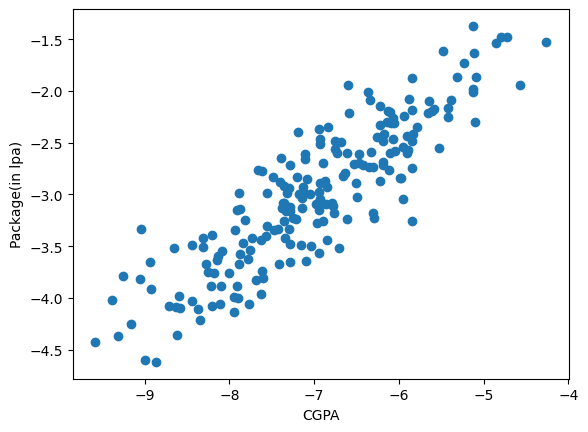

In [5]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [6]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0, 0.5, 'Package(in lpa)')

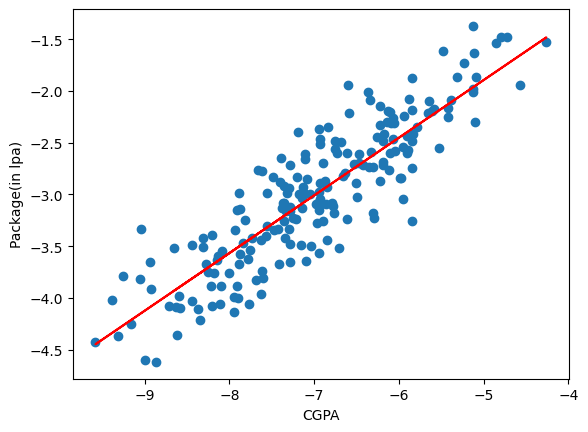

In [11]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [12]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [16]:
y_pred=lr.predict(X_test)

In [17]:
y_test.values

array([-4.1 , -3.49, -2.08, -2.33, -1.94, -1.48, -1.86, -3.09, -4.21,
       -2.87, -3.65, -4.  , -2.89, -2.6 , -2.99, -3.25, -1.86, -3.67,
       -2.37, -3.42, -2.48, -3.65, -2.6 , -2.83, -4.08, -2.56, -3.58,
       -3.81, -4.09, -2.01, -3.63, -2.92, -3.51, -1.94, -2.21, -3.34,
       -3.34, -3.23, -2.01, -2.61])

In [19]:
print('MAE:',mean_absolute_error(y_test.values,y_pred))

MAE: 0.2884710931878175


In [20]:
print('MSE:',mean_squared_error(y_test.values,y_pred))

MSE: 0.12129235313495527


In [22]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [24]:
print('R2:',r2_score(y_test.values,y_pred))
r2=r2_score(y_test.values,y_pred)

R2: 0.780730147510384


In [25]:
# adjusted r2 score
X_test.shape

(40, 1)

In [26]:
# using r2 adusted formula
1 - ((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

### adding new col randomly to check diffrent metrics

In [39]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)   # addin irrelevent col

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,-6.89,0.821533,-3.26
1,-5.12,0.233480,-1.98
2,-7.82,0.742921,-3.25
3,-7.42,0.509942,-3.67
4,-6.94,0.663421,-3.57


Text(0, 0.5, 'Package(in lpa)')

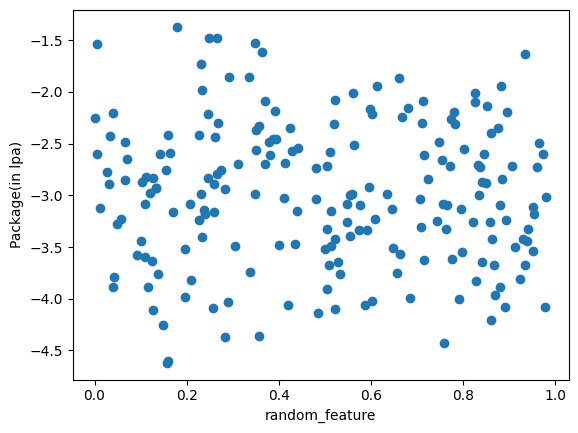

In [40]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [41]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [43]:
lr = LinearRegression()

In [44]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
y_pred = lr.predict(X_test)

In [46]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.783715157158885


In [47]:
# adjusted r2score
1 - ((1-r2)*(40-1)/(40-1-2))

0.7720240845728787

In [ ]:
-> on adding irrelvent col 

In [48]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10) # adding new col (relevent col)

new_df2 = new_df2[['cgpa','iq','package']]

In [49]:
new_df2.sample(5)

,cgpa,iq,package
63,-9.16,-4.45,-4.25
68,-7.56,-3.29,-2.99
105,-6.66,-2.82,-2.82
136,-5.64,-2.10,-2.10
166,-8.60,-3.38,-3.98


Text(0, 0.5, 'Package(in lpa)')

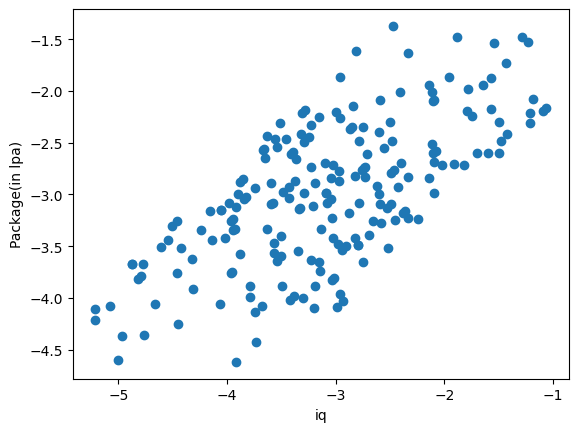

In [50]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [52]:
np.random.randint(-100,100)

-68

In [53]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [55]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [56]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8115587051819709


In [57]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.8013726892458612

-> on adding relevent col r2 score increases